# Implementasi Credit Scoring Berbasis Trustworthy AI

**Studi kasus:** AI untuk penilaian risiko kredit (*credit scoring*)  
**Dataset:** German Credit Data versi `credit-g.csv` dari OpenML Datasets  
**Fokus:** Regulasi AI, Trustworthy AI, fairness, accountability, transparency, dan SDGs.

Notebook ini dibuat agar dapat langsung dijalankan dengan **Run All** di Google Colab dan juga nyaman dipakai sebagai bahan presentasi.  
Setiap bagian notebook tidak hanya berisi kode, tetapi juga dilengkapi dengan:

- **Pengertian pipeline/tahap**, yaitu fungsi utama dari bagian tersebut.
- **Alur input → proses → output**, supaya hubungan antar bagian mudah dipahami.
- **Catatan presenter**, yaitu contoh kalimat yang bisa diucapkan saat menjelaskan notebook.
- **Jembatan ke pipeline berikutnya**, supaya presentasi terdengar mengalir dan tidak putus-putus.

> **Cara membaca notebook ini saat presentasi:**  
> Ikuti urutan dari atas ke bawah. Jangan langsung fokus pada kode, tetapi jelaskan dulu *mengapa tahap itu dilakukan*, *apa yang diproses*, dan *hasilnya dipakai untuk tahap apa berikutnya*.

> **Versi online-ready:** Notebook ini sudah dilengkapi penjelasan pipeline dan disiapkan untuk dibuka melalui GitHub/Google Colab atau didampingi web app Streamlit.

## ☁️ Cara Akses Online untuk Dosen

Bagian ini disiapkan agar notebook bisa dibuka secara online oleh dosen tanpa harus menerima file mentah saja. Ada dua cara yang disarankan:

1. **Google Colab / GitHub Notebook**  
   Cocok jika dosen ingin membaca alur notebook dan menjalankan ulang cell. Upload file ini ke GitHub, lalu buka melalui Google Colab menggunakan format link:
   `https://colab.research.google.com/github/USERNAME/NAMA_REPO/blob/main/Implementasi_Credit_Scoring_Trustworthy_AI_online_ready.ipynb`

2. **Streamlit Web App**  
   Cocok jika dosen ingin melihat versi interaktif berbasis web. Gunakan file `app.py` dan `requirements.txt` yang ada dalam paket deploy. Setelah di-deploy, dosen cukup membuka link aplikasi.

### Narasi presenter
“Notebook ini sudah kami siapkan supaya bisa dibuka online. Jadi dosen tidak hanya melihat file lokal, tetapi juga bisa membuka versi Colab atau mencoba web app sederhana yang menampilkan dataset, pipeline preprocessing, performa model, evaluasi fairness, dan simulasi prediksi risiko kredit.”


## Peta Alur Pipeline Notebook

Bagian ini dapat dipakai sebagai ringkasan alur saat membuka presentasi notebook.

| No | Pipeline/Tahap | Pengertian Singkat | Input Utama | Output Utama | Hubungan ke Tahap Berikutnya |
|---|---|---|---|---|---|
| 1 | Instalasi library | Menyiapkan environment kerja | Google Colab/Python | Library siap digunakan | Library kemudian diimpor |
| 2 | Import library | Memanggil alat analisis | Library Python | Fungsi dan class tersedia | Dipakai untuk load dan analisis data |
| 3 | Load dataset | Membaca data mentah | URL dataset | DataFrame `df` | Data dipahami pada data understanding |
| 4 | Data understanding | Mengecek struktur dan kualitas data | `df` | Informasi kolom, tipe data, missing value | Menentukan target dan fitur |
| 5 | Target classification | Menentukan label yang diprediksi | Kolom `class` | Kolom `target` numerik | Dipakai untuk distribusi dan training |
| 6 | Distribusi target | Mengecek keseimbangan kelas | `target` | Jumlah dan persentase kelas | Menentukan strategi evaluasi |
| 7 | Fitur & atribut sensitif | Menentukan input model dan kelompok fairness | `df`, `target`, kolom sensitif | `X`, `y`, `sensitive_features` | Dipakai saat split data |
| 8 | Train-test split | Membagi data train dan test | `X`, `y`, `sensitive_features` | Data latih dan data uji | Dipakai untuk preprocessing dan training |
| 9 | Preprocessing | Mengubah data siap model | Fitur numerik dan kategorikal | `preprocessor` | Digabung ke pipeline model |
| 10 | Training model | Melatih dan membandingkan model | Data train dan `preprocessor` | `trained_models`, `results_df` | Model terbaik dipilih |
| 11 | Evaluasi terbaik | Mengevaluasi model terbaik | `results_df`, model terbaik | Classification report & confusion matrix | Dilanjutkan evaluasi fairness |
| 12 | Fairness | Membandingkan performa antar kelompok | `y_test`, prediksi, sensitive group | `fairness_df`, difference, ratio | Menilai risiko bias |
| 13 | Interpretasi | Menjelaskan faktor penting model | Model terbaik | Feature importance/koefisien | Menguatkan transparency |
| 14 | Trustworthy AI | Menghubungkan teknis dengan prinsip AI tepercaya | Hasil evaluasi | Analisis fairness, accountability, transparency, ethics | Dikaitkan dengan regulasi dan SDGs |
| 15 | Regulasi & SDGs | Menjelaskan dampak sosial dan aturan | Analisis Trustworthy AI | Relevansi regulasi, SDG 8, SDG 10 | Menjadi bahan kesimpulan |
| 16 | Kesimpulan | Merangkum hasil akhir | Seluruh output notebook | Narasi penutup presentasi | Selesai |

### Narasi pembuka alur
“Notebook ini disusun sebagai pipeline end-to-end. Alurnya dimulai dari menyiapkan environment, memuat dan memahami dataset, menentukan target, melakukan preprocessing, melatih beberapa model, memilih model terbaik, lalu mengevaluasi fairness dan interpretasi model. Jadi, eksperimen ini tidak hanya berhenti pada akurasi, tetapi juga menghubungkan hasil teknis dengan prinsip Trustworthy AI.”


## 1. Instalasi Library Tambahan

### Pengertian pipeline ini
Pipeline pertama adalah **menyiapkan lingkungan kerja**. Sebelum data diproses dan model dibangun, library yang dibutuhkan harus tersedia terlebih dahulu.

### Alur input → proses → output
- **Input:** Google Colab atau environment Python yang akan digunakan.
- **Proses:** Menginstal library tambahan, terutama `fairlearn`.
- **Output:** Environment siap digunakan untuk menjalankan analisis machine learning dan evaluasi fairness.

### Catatan presenter
“Pada tahap pertama, kami memastikan semua library yang dibutuhkan tersedia. Library umum seperti pandas, numpy, matplotlib, dan scikit-learn biasanya sudah tersedia di Google Colab. Namun, untuk evaluasi fairness, kami menggunakan library tambahan yaitu Fairlearn. Jadi tahap ini berfungsi sebagai persiapan environment sebelum masuk ke proses analisis data.”

### Jembatan ke pipeline berikutnya
Setelah library tersedia, tahap berikutnya adalah **mengimpor library** agar fungsi-fungsi tersebut bisa dipakai dalam notebook.


In [ ]:
# Jalankan cell ini di Google Colab jika fairlearn belum tersedia
!pip -q install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 704.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.5 MB/s eta 0:00:00


## 2. Import Library

### Pengertian pipeline ini
Pipeline ini berfungsi untuk **memanggil semua alat kerja** yang akan digunakan selama eksperimen. Analogi sederhananya, sebelum membangun model, kita menyiapkan dulu semua “peralatan” seperti library untuk mengolah data, membuat grafik, melakukan preprocessing, melatih model, dan mengevaluasi hasil.

### Alur input → proses → output
- **Input:** Library yang sudah tersedia di environment.
- **Proses:** Mengimpor modul yang dibutuhkan dari `pandas`, `numpy`, `matplotlib`, `scikit-learn`, dan `fairlearn`.
- **Output:** Semua fungsi dan class siap dipakai pada pipeline berikutnya.

### Fungsi library utama
- `pandas` digunakan untuk membaca dan mengolah data tabel.
- `numpy` digunakan untuk operasi numerik.
- `matplotlib` digunakan untuk visualisasi grafik.
- `scikit-learn` digunakan untuk preprocessing, split data, training model, dan evaluasi performa.
- `fairlearn` digunakan untuk mengevaluasi fairness model antar kelompok sensitif.

### Catatan presenter
“Setelah environment siap, kami mengimpor library yang dibutuhkan. Bagian ini penting karena seluruh proses setelah ini bergantung pada library tersebut. Misalnya, pandas digunakan untuk data, scikit-learn untuk machine learning, dan fairlearn untuk mengecek apakah model memiliki indikasi bias terhadap kelompok tertentu.”

### Jembatan ke pipeline berikutnya
Setelah alat kerja siap, tahap berikutnya adalah **memuat dataset** yang akan dianalisis.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from fairlearn.metrics import MetricFrame, selection_rate

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 3. Load Dataset

### Pengertian pipeline ini
Pipeline ini adalah tahap **memasukkan data mentah** ke dalam notebook. Dataset yang digunakan adalah German Credit Data, yaitu dataset yang sering digunakan untuk eksperimen credit scoring.

### Alur input → proses → output
- **Input:** URL dataset `credit-g.csv`.
- **Proses:** Dataset dibaca menggunakan `pd.read_csv()`.
- **Output:** Data tersimpan dalam variabel `df` berbentuk DataFrame.

### Mengapa tahap ini penting?
Model machine learning tidak bisa langsung dibuat tanpa data. Oleh karena itu, tahap load dataset menjadi pintu masuk utama dari seluruh pipeline. Semua tahap berikutnya, mulai dari data understanding sampai evaluasi fairness, menggunakan data yang dimuat pada tahap ini.

### Catatan presenter
“Pada tahap ini, dataset dimuat langsung dari URL GitHub menggunakan pandas. Setelah data berhasil dibaca, hasilnya disimpan ke dalam variabel `df`. Variabel inilah yang akan menjadi sumber utama untuk proses analisis, preprocessing, training model, dan evaluasi.”

### Jembatan ke pipeline berikutnya
Setelah data dimuat, kita belum bisa langsung membuat model. Kita perlu memahami dulu isi dan kualitas datanya melalui tahap **data understanding**.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasets/openml-datasets/main/data/credit-g/credit-g.csv"
df = pd.read_csv(url)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,'<0',6,'critical/other existing credit',radio/tv,1169,'no known savings','>=7',4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,'0<=X<200',48,'existing paid',radio/tv,5951,'<100','1<=X<4',2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,'<100','4<=X<7',2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,'<0',42,'existing paid',furniture/equipment,7882,'<100','4<=X<7',2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,'<0',24,'delayed previously','new car',4870,'<100','1<=X<4',3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


### Cara menjelaskan output cell ini
Output `df.head()` menampilkan lima baris pertama dataset. Tujuannya bukan untuk menganalisis semua data, tetapi untuk memastikan dataset berhasil terbaca dan melihat gambaran awal bentuk kolom serta nilainya.


## 4. Data Understanding

### Pengertian pipeline ini
Data understanding adalah tahap **mengenali karakteristik dataset** sebelum dilakukan preprocessing atau modeling. Tujuannya agar kita tahu bentuk data, jumlah fitur, tipe data, missing value, dan potensi masalah pada dataset.

### Alur input → proses → output
- **Input:** DataFrame `df` hasil load dataset.
- **Proses:** Mengecek ukuran dataset, daftar kolom, tipe data, missing value, dan data duplikat.
- **Output:** Gambaran awal kualitas dan struktur dataset.

### Hal yang diperiksa
1. **Ukuran dataset** untuk mengetahui jumlah baris dan kolom.
2. **Daftar kolom** untuk mengetahui fitur apa saja yang tersedia.
3. **Tipe data** untuk membedakan fitur numerik dan kategorikal.
4. **Missing value** untuk mengecek apakah ada data kosong.
5. **Duplikasi** untuk melihat apakah terdapat data yang berulang.

### Catatan presenter
“Sebelum masuk ke model, kami melakukan data understanding terlebih dahulu. Tahap ini penting karena kualitas data sangat memengaruhi kualitas model. Jika terdapat missing value, tipe data yang tidak sesuai, atau data duplikat, maka hal tersebut perlu diketahui sejak awal agar keputusan preprocessing lebih tepat.”

### Jembatan ke pipeline berikutnya
Setelah memahami struktur data, tahap berikutnya adalah menentukan **target klasifikasi**, yaitu kolom yang akan diprediksi oleh model.


In [ ]:
print("Ukuran dataset:", df.shape)
print("\nDaftar kolom:")
print(df.columns.tolist())

print("\nInformasi dataset:")
df.info()

Ukuran dataset: (1000, 21)

Daftar kolom:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_comm

In [ ]:
print("Jumlah missing value per kolom:")
df.isna().sum().sort_values(ascending=False)

Jumlah missing value per kolom:


,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


In [ ]:
print("Jumlah duplikasi:", df.duplicated().sum())

Jumlah duplikasi: 0


### Transisi setelah data understanding
Jika ukuran data, tipe data, missing value, dan duplikasi sudah diketahui, maka kita bisa lanjut menentukan kolom target. Tahap ini penting karena model harus tahu variabel mana yang akan diprediksi.


## 5. Menentukan Target Klasifikasi

### Pengertian pipeline ini
Pipeline ini menentukan **apa yang ingin diprediksi oleh model**. Pada kasus credit scoring, targetnya adalah status risiko kredit, yaitu apakah nasabah termasuk risiko kredit baik atau buruk.

### Alur input → proses → output
- **Input:** Kolom `class` dari dataset.
- **Proses:** Mengubah label teks menjadi angka agar bisa diproses oleh model.
- **Output:** Kolom baru `target` dengan nilai numerik.

### Skema encoding target
- `good` → `0`, artinya **good credit risk**.
- `bad` → `1`, artinya **bad credit risk**.

Dalam eksperimen ini, kelas `bad` dijadikan kelas positif karena yang ingin dideteksi secara khusus adalah calon peminjam dengan risiko kredit buruk.

### Catatan presenter
“Target pada dataset ini awalnya berbentuk teks, yaitu good dan bad. Karena model machine learning membutuhkan target numerik, maka label tersebut diubah menjadi 0 dan 1. Di sini bad diberi nilai 1 karena dalam credit scoring, risiko buruk adalah kelas yang paling perlu diperhatikan.”

### Jembatan ke pipeline berikutnya
Setelah target dibuat, kita perlu melihat apakah jumlah data pada masing-masing kelas seimbang atau tidak melalui tahap **distribusi target**.


In [ ]:
target_col = "class"

print("Nilai unik target sebelum encoding:")
print(df[target_col].value_counts())

df["target"] = df[target_col].map({
    "good": 0,
    "bad": 1
})

print("\nNilai unik target setelah encoding:")
print(df["target"].value_counts())

Nilai unik target sebelum encoding:
class
good    700
bad     300
Name: count, dtype: int64

Nilai unik target setelah encoding:
target
0    700
1    300
Name: count, dtype: int64


### Cara menjelaskan output cell ini
Output sebelum encoding menunjukkan label asli dari dataset, yaitu `good` dan `bad`. Output setelah encoding menunjukkan bahwa label tersebut sudah diubah menjadi angka, sehingga siap digunakan untuk proses klasifikasi.


## 6. Cek Distribusi Target dan Balanced Dataset

### Pengertian pipeline ini
Pipeline ini bertujuan untuk mengecek apakah dataset memiliki jumlah kelas yang seimbang. Dalam klasifikasi, distribusi target penting karena model dapat menjadi bias terhadap kelas mayoritas.

### Alur input → proses → output
- **Input:** Kolom `target` yang sudah dibuat.
- **Proses:** Menghitung jumlah dan persentase kelas `0` dan `1`, lalu divisualisasikan.
- **Output:** Informasi apakah dataset cenderung balanced atau tidak.

### Mengapa tidak cukup hanya melihat accuracy?
Jika kelas `good` jauh lebih banyak dari `bad`, model bisa mendapatkan accuracy tinggi hanya dengan sering memprediksi `good`. Padahal, model tersebut belum tentu baik dalam mendeteksi `bad credit risk`.

Karena itu, hasil distribusi target akan memengaruhi keputusan evaluasi model. Pada kasus seperti ini, metrik seperti **precision**, **recall**, dan **F1-score** menjadi lebih penting daripada hanya accuracy.

### Catatan presenter
“Pada tahap ini, kami mengecek distribusi kelas target. Tujuannya untuk mengetahui apakah data good dan bad seimbang. Jika tidak seimbang, model bisa cenderung mempelajari kelas yang jumlahnya lebih banyak. Karena itu, nanti evaluasi model tidak hanya memakai accuracy, tetapi juga precision, recall, dan F1-score.”

### Jembatan ke pipeline berikutnya
Setelah mengetahui kondisi target, tahap berikutnya adalah menentukan **fitur input** dan **atribut sensitif** untuk evaluasi fairness.


In [ ]:
class_counts = df["target"].value_counts().sort_index()
class_percent = df["target"].value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    "Kelas": ["Good credit risk (0)", "Bad credit risk (1)"],
    "Jumlah": class_counts.values,
    "Persentase (%)": class_percent.round(2).values
})

dist_df

,Kelas,Jumlah,Persentase (%)
0,Good credit risk (0),700,70.0
1,Bad credit risk (1),300,30.0


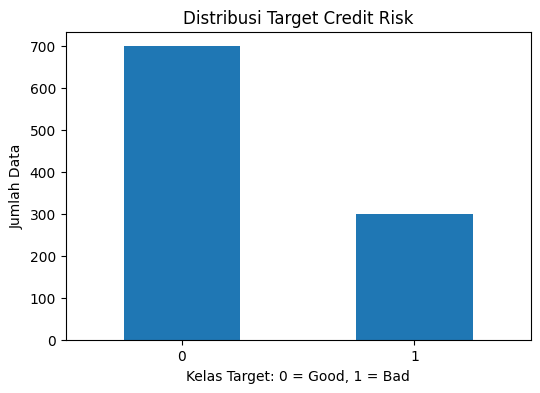

In [ ]:
plt.figure(figsize=(6, 4))
df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Target Credit Risk")
plt.xlabel("Kelas Target: 0 = Good, 1 = Bad")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

In [ ]:
majority_ratio = class_counts.max() / class_counts.sum()

print(f"Rasio kelas mayoritas: {majority_ratio:.2%}")

if majority_ratio > 0.65:
    print("Dataset cenderung tidak balanced. Gunakan stratify dan pertimbangkan balancing sederhana.")
else:
    print("Dataset relatif cukup balanced untuk eksperimen sederhana.")

Rasio kelas mayoritas: 70.00%
Dataset cenderung tidak balanced. Gunakan stratify dan pertimbangkan balancing sederhana.


### Transisi setelah distribusi target
Hasil distribusi target membantu menentukan strategi evaluasi. Jika kelas tidak seimbang, maka evaluasi perlu melihat F1-score, precision, dan recall, bukan hanya accuracy.


## 7. Menentukan Fitur dan Atribut Sensitif

### Pengertian pipeline ini
Pipeline ini menentukan dua hal penting:

1. **Fitur input**, yaitu kolom-kolom yang akan digunakan model untuk membuat prediksi.
2. **Atribut sensitif**, yaitu kolom yang digunakan untuk mengevaluasi fairness antar kelompok.

### Alur input → proses → output
- **Input:** Dataset `df` yang sudah memiliki kolom `target`.
- **Proses:** Mengecek kolom yang tersedia, membuat `age_group`, dan memilih atribut sensitif.
- **Output:** Variabel `sensitive_col` yang akan digunakan pada evaluasi fairness.

### Mengapa atribut sensitif dibutuhkan?
Dalam Trustworthy AI, fairness tidak bisa dinilai hanya dari performa keseluruhan. Kita perlu melihat apakah model bekerja secara berbeda pada kelompok tertentu. Misalnya, model mungkin memiliki recall tinggi pada satu kelompok, tetapi rendah pada kelompok lain.

Pada notebook ini, atribut sensitif yang digunakan adalah:
- `personal_status` jika tersedia, karena mengandung informasi status personal dan jenis kelamin.
- `age_group` sebagai alternatif, yaitu pengelompokan usia menjadi `younger` dan `older`.

### Catatan presenter
“Pada tahap ini, kami mulai menghubungkan machine learning dengan Trustworthy AI. Selain menentukan fitur untuk model, kami juga menentukan atribut sensitif untuk evaluasi fairness. Atribut sensitif ini digunakan untuk melihat apakah performa model berbeda antar kelompok tertentu.”

### Jembatan ke pipeline berikutnya
Setelah fitur dan atribut sensitif ditentukan, data perlu dibagi menjadi data latih dan data uji melalui tahap **train-test split**.


In [ ]:
# Cek kolom yang tersedia
df.columns.tolist()

['checking_status',
 'duration',
 'credit_history',
 'purpose',
 'credit_amount',
 'savings_status',
 'employment',
 'installment_commitment',
 'personal_status',
 'other_parties',
 'residence_since',
 'property_magnitude',
 'age',
 'other_payment_plans',
 'housing',
 'existing_credits',
 'job',
 'num_dependents',
 'own_telephone',
 'foreign_worker',
 'class',
 'target']

In [ ]:
# Membuat age_group jika kolom age tersedia
if "age" in df.columns:
    df["age_group"] = np.where(df["age"] < df["age"].median(), "younger", "older")
else:
    df["age_group"] = "unknown"

# Menentukan sensitive feature utama
if "personal_status" in df.columns:
    sensitive_col = "personal_status"
else:
    sensitive_col = "age_group"

print("Atribut sensitif yang digunakan untuk evaluasi fairness:", sensitive_col)
print(df[sensitive_col].value_counts())

Atribut sensitif yang digunakan untuk evaluasi fairness: personal_status
personal_status
'male single'           548
'female div/dep/mar'    310
'male mar/wid'           92
'male div/sep'           50
Name: count, dtype: int64


### Cara menjelaskan output cell ini
Output ini menunjukkan atribut sensitif yang dipakai untuk fairness. Atribut ini tidak digunakan untuk membuat kesimpulan diskriminasi secara langsung, tetapi menjadi dasar untuk membandingkan performa model antar kelompok.


## 8. Split Data dengan Stratify

### Pengertian pipeline ini
Pipeline ini membagi dataset menjadi dua bagian:

- **Data train**, digunakan untuk melatih model.
- **Data test**, digunakan untuk menguji model pada data yang belum pernah dilihat sebelumnya.

### Alur input → proses → output
- **Input:** Fitur `X`, target `y`, dan `sensitive_features`.
- **Proses:** Membagi data menggunakan `train_test_split()` dengan `stratify=y`.
- **Output:** `X_train`, `X_test`, `y_train`, `y_test`, `sensitive_train`, dan `sensitive_test`.

### Mengapa menggunakan stratify?
`stratify=y` digunakan agar proporsi kelas target pada data train dan test tetap mirip dengan dataset asli. Ini penting terutama jika data tidak sepenuhnya balanced.

Jika stratify tidak digunakan, bisa saja data test memiliki proporsi kelas yang kurang representatif. Akibatnya, evaluasi model menjadi kurang stabil.

### Catatan presenter
“Data dibagi menjadi 80 persen data latih dan 20 persen data uji. Kami menggunakan stratify agar proporsi good dan bad tetap terjaga pada data train dan test. Dengan begitu, evaluasi model menjadi lebih adil dan tidak terlalu dipengaruhi oleh pembagian data yang kebetulan tidak seimbang.”

### Jembatan ke pipeline berikutnya
Setelah data dibagi, fitur input masih perlu diproses karena terdapat fitur numerik dan kategorikal. Tahap berikutnya adalah **preprocessing**.


In [ ]:
# Fitur yang tidak digunakan sebagai input model
drop_cols = [target_col, "target"]

X = df.drop(columns=drop_cols)
y = df["target"]

# Simpan sensitive feature sebelum split untuk fairness evaluation
sensitive_features = df[sensitive_col]

X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive_features,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

print("\nDistribusi target pada data train:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribusi target pada data test:")
print(y_test.value_counts(normalize=True).round(3))

Ukuran X_train: (800, 21)
Ukuran X_test : (200, 21)

Distribusi target pada data train:
target
0    0.7
1    0.3
Name: proportion, dtype: float64

Distribusi target pada data test:
target
0    0.7
1    0.3
Name: proportion, dtype: float64


### Cara menjelaskan output cell ini
Output ukuran `X_train` dan `X_test` menunjukkan hasil pembagian data. Distribusi target pada train dan test dicek untuk memastikan proporsi kelas tetap mirip setelah split.


## 9. Preprocessing

### Pengertian pipeline ini
Preprocessing adalah tahap **mengubah data mentah menjadi format yang siap dipakai oleh model**. Dataset credit scoring memiliki kombinasi fitur numerik dan kategorikal, sehingga keduanya perlu diproses dengan cara berbeda.

### Alur input → proses → output
- **Input:** Fitur `X` dari dataset.
- **Proses:** Memisahkan fitur numerik dan kategorikal, lalu membuat `ColumnTransformer`.
- **Output:** Objek `preprocessor` yang akan dimasukkan ke dalam model pipeline.

### Teknik preprocessing yang digunakan
- **Fitur numerik** diproses dengan `StandardScaler`, supaya skala nilainya lebih seimbang.
- **Fitur kategorikal** diproses dengan `OneHotEncoder`, supaya kategori teks berubah menjadi representasi numerik.
- **ColumnTransformer** digunakan agar preprocessing numerik dan kategorikal berjalan otomatis sesuai jenis kolomnya.

### Mengapa preprocessing dibuat sebagai objek pipeline?
Preprocessing dimasukkan ke pipeline agar proses training dan testing konsisten. Artinya, data train dan data test diproses dengan aturan yang sama, sehingga mengurangi risiko kesalahan eksperimen.

### Catatan presenter
“Pada tahap preprocessing, fitur numerik dan kategorikal diproses secara berbeda. Fitur numerik distandarkan dengan StandardScaler, sedangkan fitur kategorikal diubah menggunakan OneHotEncoder. Semua proses ini digabung dengan ColumnTransformer agar preprocessing berjalan otomatis dan rapi.”

### Jembatan ke pipeline berikutnya
Setelah preprocessing siap, tahap berikutnya adalah menggabungkan preprocessing dan classifier ke dalam **machine learning pipeline** untuk training model.


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Fitur numerik:")
print(numeric_features)

print("\nFitur kategorikal:")
print(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Fitur numerik:
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Fitur kategorikal:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'age_group']


### Transisi setelah preprocessing
Setelah fitur numerik dan kategorikal dikenali, objek `preprocessor` siap digunakan. Objek ini akan digabungkan dengan classifier agar setiap model menerima data yang sudah diproses secara konsisten.


## 10. Training Model

### Pengertian pipeline ini
Pipeline ini adalah inti dari proses machine learning. Pada tahap ini, model dilatih untuk mempelajari pola dari data train, lalu diuji pada data test.

### Alur input → proses → output
- **Input:** `X_train`, `y_train`, `X_test`, `y_test`, dan objek `preprocessor`.
- **Proses:** Membuat `Pipeline` berisi preprocessing dan classifier, lalu melatih model dengan `.fit()`.
- **Output:** Model yang sudah terlatih, prediksi data test, dan tabel hasil evaluasi awal.

### Model yang dibandingkan
1. **Logistic Regression**  
   Model linear yang sederhana dan relatif mudah dijelaskan.
2. **Decision Tree**  
   Model berbentuk pohon keputusan, mudah dipahami karena mirip aturan if-else.
3. **Random Forest**  
   Gabungan banyak decision tree yang biasanya lebih stabil, tetapi interpretasinya lebih kompleks.

### Apa arti `Pipeline` pada kode?
Di scikit-learn, `Pipeline` digunakan untuk menyatukan dua proses utama:

1. `preprocess`: mengubah data mentah menjadi data siap model.
2. `classifier`: melakukan training dan prediksi.

Dengan pipeline, setiap model mendapatkan proses preprocessing yang sama. Ini membuat perbandingan antar model menjadi lebih adil.

### Catatan presenter
“Pada tahap training, kami membandingkan tiga model. Setiap model dimasukkan ke dalam pipeline yang sama, yaitu preprocessing terlebih dahulu lalu classifier. Dengan cara ini, perbandingan model menjadi konsisten karena semua model menerima data yang sudah diproses dengan aturan yang sama.”

### Jembatan ke pipeline berikutnya
Setelah semua model dilatih dan menghasilkan metrik, tahap berikutnya adalah memilih dan mengevaluasi **model terbaik**.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=7)
}

trained_models = {}
results = []

for model_name, classifier in models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    trained_models[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.780,0.666667,0.533333,0.592593
1,Decision Tree,0.645,0.417910,0.466667,0.440945
2,Random Forest,0.765,0.760000,0.316667,0.447059


### Cara menjelaskan output cell ini
Tabel `results_df` memperlihatkan perbandingan performa tiga model. Dari tabel ini, kita dapat melihat bahwa pemilihan model tidak hanya berdasarkan satu metrik, tetapi mempertimbangkan accuracy, precision, recall, dan F1-score.


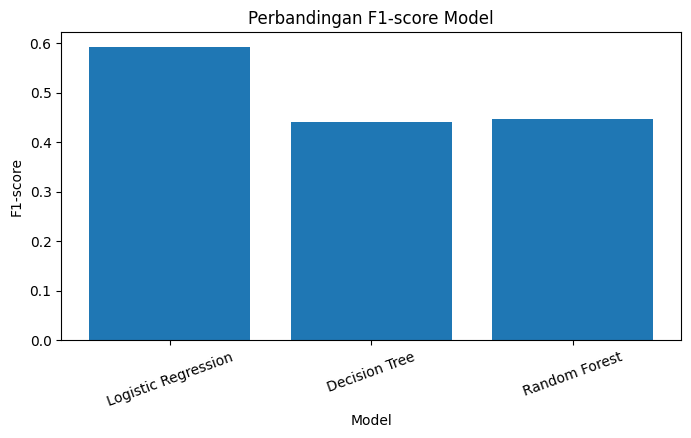

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Perbandingan F1-score Model")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.show()

## 11. Evaluasi Model Terbaik

### Pengertian pipeline ini
Pipeline ini memilih model terbaik berdasarkan hasil evaluasi, kemudian mengevaluasi model tersebut secara lebih detail.

### Alur input → proses → output
- **Input:** Tabel `results_df` dan model yang sudah dilatih pada `trained_models`.
- **Proses:** Memilih model dengan F1-score tertinggi, membuat prediksi, dan menampilkan classification report serta confusion matrix.
- **Output:** Nama model terbaik, performa detail, dan visualisasi kesalahan prediksi.

### Mengapa F1-score digunakan?
F1-score digunakan karena menggabungkan precision dan recall. Pada credit scoring, kita perlu menyeimbangkan dua risiko:

- Terlalu banyak memprediksi nasabah sebagai `bad`, padahal sebenarnya `good`.
- Gagal mendeteksi nasabah yang sebenarnya `bad`, tetapi diprediksi `good`.

### Cara membaca confusion matrix
Confusion matrix membantu melihat jenis prediksi benar dan salah:
- **Good diprediksi Good:** keputusan benar untuk risiko baik.
- **Bad diprediksi Bad:** keputusan benar untuk risiko buruk.
- **Good diprediksi Bad:** calon peminjam layak bisa saja ditolak.
- **Bad diprediksi Good:** risiko gagal bayar bisa tidak terdeteksi.

### Catatan presenter
“Model terbaik dipilih berdasarkan F1-score, bukan hanya accuracy. Hal ini karena dalam credit scoring, kesalahan pada kelas bad risk perlu diperhatikan. Setelah model terbaik dipilih, kami melihat classification report dan confusion matrix untuk memahami performa model secara lebih detail.”

### Jembatan ke pipeline berikutnya
Setelah performa umum diketahui, tahap berikutnya adalah mengecek apakah performa tersebut **adil antar kelompok sensitif** melalui evaluasi fairness.


In [ ]:
best_model_name = results_df.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Model terbaik berdasarkan F1-score:", best_model_name)

y_pred_best = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Good Risk", "Bad Risk"], zero_division=0))

Model terbaik berdasarkan F1-score: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

   Good Risk       0.82      0.89      0.85       140
    Bad Risk       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



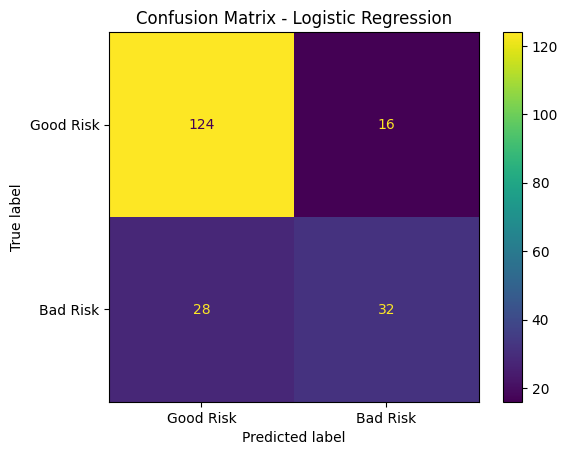

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good Risk", "Bad Risk"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

### Transisi setelah evaluasi model terbaik
Setelah model terbaik dievaluasi secara umum, pertanyaan berikutnya adalah apakah model tersebut bekerja sama baiknya pada setiap kelompok sensitif. Inilah alasan kita masuk ke evaluasi fairness.


## 12. Evaluasi Fairness Sederhana

### Pengertian pipeline ini
Pipeline ini mengevaluasi apakah model memiliki performa yang berbeda antar kelompok sensitif. Ini adalah bagian penting dari Trustworthy AI, karena model yang akurat secara umum belum tentu adil untuk semua kelompok.

### Alur input → proses → output
- **Input:** `y_test`, `y_pred_best`, dan `sensitive_test`.
- **Proses:** Menggunakan `MetricFrame` dari Fairlearn untuk menghitung metrik per kelompok.
- **Output:** Tabel fairness per kelompok, visualisasi metrik, difference, dan ratio antar kelompok.

### Metrik fairness yang digunakan
- **Accuracy:** seberapa banyak prediksi benar pada tiap kelompok.
- **Precision:** dari prediksi bad risk, berapa yang benar-benar bad risk.
- **Recall:** dari semua bad risk sebenarnya, berapa yang berhasil dideteksi.
- **F1-score:** keseimbangan precision dan recall.
- **Selection rate:** seberapa sering model memberi prediksi positif pada kelompok tertentu.

### Cara membaca hasil fairness
Jika perbedaan metrik antar kelompok terlalu besar, maka ada indikasi bahwa model bekerja tidak seimbang. Namun, hasil ini belum langsung membuktikan diskriminasi. Hasil fairness perlu dianalisis lebih lanjut dengan konteks data, regulasi, dan dampak sosial.

### Catatan presenter
“Pada tahap fairness, kami tidak hanya melihat performa model secara keseluruhan. Kami membandingkan metrik model pada masing-masing kelompok sensitif. Jika ada kelompok yang performanya jauh lebih rendah atau selection rate-nya berbeda jauh, maka model perlu dianalisis lebih lanjut karena berpotensi tidak adil.”

### Jembatan ke pipeline berikutnya
Setelah fairness dievaluasi, tahap berikutnya adalah mencoba memahami **fitur apa saja yang paling memengaruhi keputusan model**.


In [ ]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "precision": precision_score,
        "recall": recall_score,
        "f1_score": f1_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sensitive_test
)

fairness_df = metric_frame.by_group
fairness_df

,accuracy,precision,recall,f1_score,selection_rate
personal_status,,,,,
'female div/dep/mar',0.770492,0.65,0.650000,0.650000,0.327869
'male div/sep',0.666667,0.50,1.000000,0.666667,0.666667
'male mar/wid',0.916667,1.00,0.666667,0.800000,0.166667
'male single',0.779661,0.70,0.411765,0.518519,0.169492


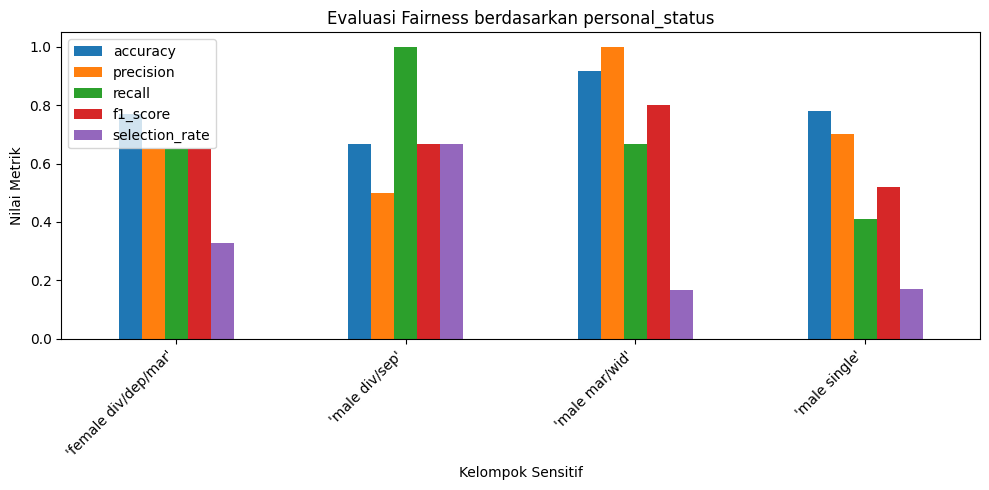

In [ ]:
fairness_df.plot(kind="bar", figsize=(10, 5))
plt.title(f"Evaluasi Fairness berdasarkan {sensitive_col}")
plt.xlabel("Kelompok Sensitif")
plt.ylabel("Nilai Metrik")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [ ]:
print("Perbedaan maksimum dan minimum antar kelompok:")
display(metric_frame.difference(method="between_groups"))

print("\nRasio minimum dan maksimum antar kelompok:")
display(metric_frame.ratio(method="between_groups"))

Perbedaan maksimum dan minimum antar kelompok:


,0
accuracy,0.250000
precision,0.500000
recall,0.588235
f1_score,0.281481
selection_rate,0.500000



Rasio minimum dan maksimum antar kelompok:


,0
accuracy,0.727273
precision,0.500000
recall,0.411765
f1_score,0.648148
selection_rate,0.250000


### Cara menjelaskan output fairness
`fairness_df` menunjukkan metrik per kelompok. `difference` menunjukkan selisih performa antar kelompok, sedangkan `ratio` menunjukkan perbandingan proporsionalnya. Semakin besar selisih atau semakin jauh rasio dari 1, semakin perlu dilakukan analisis fairness lebih lanjut.


## 13. Interpretasi Sederhana Model

### Pengertian pipeline ini
Pipeline ini digunakan untuk meningkatkan transparency atau keterjelasan model. Tujuannya adalah mengetahui fitur mana yang paling berpengaruh dalam prediksi.

### Alur input → proses → output
- **Input:** Model terbaik yang sudah dilatih dan hasil preprocessing.
- **Proses:** Mengambil nama fitur hasil preprocessing dan membaca feature importance jika tersedia.
- **Output:** Tabel dan grafik fitur paling berpengaruh.

### Mengapa interpretasi model penting?
Dalam sistem credit scoring, hasil model dapat memengaruhi keputusan finansial seseorang. Oleh karena itu, pihak pengembang dan pengguna sistem perlu memahami alasan umum di balik prediksi model.

Untuk model tree-based seperti Decision Tree dan Random Forest, interpretasi dapat dilakukan dengan `feature_importances_`. Jika model terbaik adalah Logistic Regression, interpretasi dapat dilakukan melalui koefisien model.

### Catatan presenter
“Interpretasi model membantu kita melihat fitur apa yang paling berpengaruh dalam keputusan model. Ini penting karena credit scoring tidak boleh menjadi sistem black box sepenuhnya. Semakin bisa dijelaskan modelnya, semakin mudah juga untuk dievaluasi dari sisi transparency dan accountability.”

### Jembatan ke pipeline berikutnya
Setelah performa, fairness, dan interpretasi dibahas, tahap berikutnya adalah menghubungkan hasil eksperimen dengan konsep **Trustworthy AI**.


In [ ]:
def get_feature_names_from_column_transformer(column_transformer):
    feature_names = []

    for name, transformer, columns in column_transformer.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(columns)
        else:
            names = columns

        feature_names.extend(names)

    return np.array(feature_names)

classifier = best_model.named_steps["classifier"]
feature_names = get_feature_names_from_column_transformer(best_model.named_steps["preprocess"])

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False).head(15)

    display(feature_importance_df)

    plt.figure(figsize=(8, 5))
    plt.barh(feature_importance_df["feature"][::-1], feature_importance_df["importance"][::-1])
    plt.title(f"Top 15 Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Model terbaik tidak memiliki feature_importances_.")
    print("Untuk Logistic Regression, interpretasi dapat dilakukan melalui koefisien model.")

Model terbaik tidak memiliki feature_importances_.
Untuk Logistic Regression, interpretasi dapat dilakukan melalui koefisien model.


### Transisi setelah interpretasi model
Feature importance atau koefisien model membantu menjelaskan keputusan model secara umum. Hasil ini kemudian digunakan sebagai bahan pembahasan transparency dalam Trustworthy AI.


## 14. Analisis Trustworthy AI

Bagian ini adalah jembatan dari hasil teknis notebook ke pembahasan konseptual tugas besar. Setelah model dibangun, kita perlu menjelaskan apakah sistem AI ini sudah mengarah pada prinsip Trustworthy AI.

### 1. Fairness
Model credit scoring harus dicek apakah menghasilkan performa yang terlalu berbeda antar kelompok.  
Jika terdapat perbedaan recall, precision, F1-score, atau selection rate yang besar, model dapat berisiko tidak adil.

**Kalimat presentasi:**  
“Fairness menjadi penting karena sistem kredit dapat berdampak langsung pada akses seseorang terhadap layanan keuangan. Jika model lebih sering merugikan kelompok tertentu, maka model tersebut belum bisa disebut trustworthy.”

### 2. Accountability
Seluruh proses eksperimen harus terdokumentasi, mulai dari sumber dataset, preprocessing, training model, evaluasi performa, hingga evaluasi fairness. Dokumentasi ini penting agar pihak yang membuat model dapat bertanggung jawab terhadap hasil sistem.

**Kalimat presentasi:**  
“Accountability terlihat dari proses notebook ini yang dibuat berurutan dan terdokumentasi. Mulai dari dataset, preprocessing, model, metrik evaluasi, sampai fairness dapat ditelusuri kembali.”

### 3. Transparency
Model sederhana seperti Logistic Regression dan Decision Tree lebih mudah dijelaskan dibanding model kompleks. Feature importance atau koefisien model dapat membantu menjelaskan faktor yang memengaruhi prediksi.

**Kalimat presentasi:**  
“Transparency berarti model tidak hanya menghasilkan output, tetapi juga dapat dijelaskan secara umum. Oleh karena itu, bagian interpretasi model menjadi penting.”

### 4. Ethics
Credit scoring berdampak langsung pada akses kredit. Jika model bias, maka kelompok tertentu dapat lebih sering ditolak, meskipun secara individu mereka layak mendapatkan layanan keuangan.

**Kalimat presentasi:**  
“Dari sisi etika, model credit scoring harus digunakan secara hati-hati. AI sebaiknya membantu proses pengambilan keputusan, bukan menjadi satu-satunya dasar untuk menolak atau menerima calon peminjam.”

### Jembatan ke pipeline berikutnya
Setelah konsep Trustworthy AI dijelaskan, hasil notebook perlu dikaitkan dengan **regulasi AI dan SDGs** agar relevan dengan dampak sosial yang lebih luas.


## 15. Kaitan dengan Regulasi AI dan SDGs

Bagian ini menjelaskan mengapa studi kasus credit scoring tidak hanya bersifat teknis, tetapi juga berhubungan dengan aturan, risiko, dan dampak sosial.

### Regulasi AI
Credit scoring termasuk contoh sistem AI yang sensitif karena dapat memengaruhi akses seseorang terhadap layanan keuangan. Oleh karena itu, sistem seperti ini perlu memperhatikan prinsip regulasi AI, seperti:

- pengelolaan risiko,
- transparansi,
- akuntabilitas,
- perlindungan pengguna,
- dan pengawasan terhadap potensi bias.

**Kalimat presentasi:**  
“Credit scoring termasuk sistem AI yang sensitif karena hasil prediksinya dapat memengaruhi keputusan finansial seseorang. Karena itu, sistem seperti ini harus memperhatikan aspek regulasi, terutama terkait transparansi, akuntabilitas, dan pengendalian risiko.”

### Trustworthy AI
Eksperimen ini mendukung prinsip Trustworthy AI karena tidak hanya mengevaluasi akurasi model, tetapi juga fairness, accountability, transparency, dan dampak etis.

**Kalimat presentasi:**  
“Notebook ini menunjukkan bahwa membangun AI tidak cukup hanya dengan membuat model yang akurat. Model juga perlu dievaluasi apakah adil, bisa dijelaskan, dan dapat dipertanggungjawabkan.”

### SDGs
Credit scoring yang lebih adil dapat mendukung:

- **SDG 8:** pertumbuhan ekonomi inklusif dan akses terhadap peluang ekonomi.
- **SDG 10:** pengurangan ketimpangan, terutama jika sistem kredit tidak mendiskriminasi kelompok tertentu.

**Kalimat presentasi:**  
“Jika sistem credit scoring dibuat lebih adil dan transparan, maka akses keuangan dapat menjadi lebih inklusif. Hal ini relevan dengan SDG 8 tentang pertumbuhan ekonomi dan SDG 10 tentang pengurangan ketimpangan.”

### Jembatan ke pipeline berikutnya
Tahap terakhir adalah menarik **kesimpulan** dari seluruh alur notebook, mulai dari data sampai Trustworthy AI.


## 16. Kesimpulan Akhir dan Narasi Penutup

Setelah seluruh pipeline dijalankan, kesimpulan dapat disusun berdasarkan output aktual notebook.

### Kesimpulan teknis
1. Dataset German Credit Data sesuai untuk studi kasus credit scoring karena memiliki target klasifikasi risiko kredit.
2. Target `class` berhasil diubah menjadi `target` numerik, yaitu `0` untuk good credit risk dan `1` untuk bad credit risk.
3. Distribusi target perlu diperhatikan karena data credit scoring biasanya tidak sepenuhnya balanced.
4. Train-test split menggunakan `stratify` membantu menjaga proporsi kelas pada data latih dan data uji.
5. Preprocessing dilakukan dengan memisahkan fitur numerik dan kategorikal, lalu digabungkan ke dalam `ColumnTransformer`.
6. Model dibandingkan menggunakan pipeline yang sama agar proses preprocessing dan training berjalan konsisten.
7. Model terbaik dipilih berdasarkan F1-score karena metrik ini lebih cocok ketika kelas target tidak sepenuhnya seimbang.
8. Evaluasi fairness dilakukan untuk melihat perbedaan performa model antar kelompok sensitif.
9. Interpretasi model membantu menjelaskan fitur yang paling berpengaruh terhadap prediksi.

### Kesimpulan Trustworthy AI
Dari sisi Trustworthy AI, notebook ini menunjukkan bahwa sistem AI untuk credit scoring harus memperhatikan:

- **Fairness**, agar model tidak merugikan kelompok tertentu.
- **Transparency**, agar keputusan model dapat dijelaskan.
- **Accountability**, agar proses pengembangan model dapat ditelusuri dan dipertanggungjawabkan.
- **Ethics**, karena keputusan kredit dapat berdampak langsung pada kehidupan seseorang.
- **Regulasi AI**, karena credit scoring termasuk sistem yang sensitif dan berisiko tinggi.
- **SDGs**, terutama SDG 8 dan SDG 10 karena berkaitan dengan akses ekonomi dan pengurangan ketimpangan.

### Contoh narasi penutup presentasi
“Berdasarkan eksperimen ini, dapat disimpulkan bahwa AI dapat membantu proses credit scoring dengan memprediksi risiko kredit calon peminjam. Namun, model tidak cukup hanya dinilai dari performa seperti accuracy atau F1-score. Karena credit scoring berdampak langsung pada akses keuangan seseorang, sistem AI juga harus diuji dari sisi fairness, transparency, accountability, dan etika. Dengan pendekatan Trustworthy AI, model yang dikembangkan tidak hanya lebih akurat, tetapi juga lebih aman, adil, dan bertanggung jawab untuk digunakan.”
